## Baseline modeling - LogisticRegression

## 1. 라이브러리 로드
모델 학습, 평가, 데이터 처리 및 시각화를 위한 라이브러리를 불러온다.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    average_precision_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

## 2. 데이터 불러오기
Netflix 사용자 데이터셋을 불러온다.

In [7]:
PROJECT_ROOT = '../../'
import os

csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', 'netflix_users_train.csv')
data_df = pd.read_csv(csv_path)
data_df = pd.read_csv(csv_path, low_memory=False)

## 3. 타깃 정의 및 전처리
필요없는 'user_id' 컬럼 제외

In [8]:
#최종 dataframe
final_df = data_df.drop('user_id', axis=1)
final_df.head(2)

,age,plan_tier,is_active,monthly_spend,age_group,subscription_tenure_days,watch_count,unique_movies,total_watch_time,avg_watch_time,watch_days,recent_watch_count,days_since_last_watch,avg_progress,completion_rate,download_ratio,avg_rating
0,55.0,1,1,11.17,5,527,20,19,859.5,42.975000,19,3.0,9,43.225000,0.1,0.3,3.714286
1,40.0,1,0,7.13,4,695,7,7,528.0,75.428571,6,0.0,126,40.971429,0.0,0.0,0.000000


## 4. Feature / Target 분리
모델 학습을 위해 feature(X)와 target(y)을 분리한다.

In [ ]:
X = final_df.drop('is_active', axis=1)
y = final_df['is_active']

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

## 5. Train / Test Split
모델 평가를 위해 데이터를 학습 데이터와 테스트 데이터로 분할한다.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (6896, 16) (6896,)
Test: (1725, 16) (1725,)


## 6. Pipeline 생성
StandardScaler와 LogisticRegression 모델로 이루어 생성한다.

In [13]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

## 7. Cross Validation 설정
Stratified K-Fold를 사용하여 클래스 비율을 유지하면서 교차 검증을 수행한다.

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

## 8. Cross Validation 수행
훈련 데이터에서 교차 검증을 통해 모델 성능을 평가한다.

In [15]:
cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1-score:", cv_results['test_f1'].mean())
print("CV ROC-AUC:", cv_results['test_roc_auc'].mean())
print("CV PR-AUC:", cv_results['test_pr_auc'].mean())

CV Precision: 0.8596417666779587
CV Recall: 0.8053537284894837
CV F1-score: 0.8315533135999008
CV ROC-AUC: 0.9275495663684934
CV PR-AUC: 0.8725777231155977


## 9. 모델 학습
전체 훈련 데이터를 사용하여 모델을 학습한다.

In [17]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## 10. 테스트 데이터 예측
학습된 모델을 이용해 테스트 데이터에 대한 예측을 수행한다.

In [22]:
pred = pipeline.predict(X_test)
pred_proba = pipeline.predict_proba(X_test)[:, 1]

## 11. 모델 평가
Classification Report 및 주요 지표를 통해 모델 성능을 평가한다.

In [27]:
print("Classification Report")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print()

print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1071
           1       0.85      0.80      0.83       654

    accuracy                           0.87      1725
   macro avg       0.87      0.86      0.86      1725
weighted avg       0.87      0.87      0.87      1725

Confusion Matrix
[[979  92]
 [129 525]]

Precision: 0.8508914100486223
Recall: 0.8027522935779816
F1: 0.8261211644374509
ROC-AUC: 0.9254547894591068
PR-AUC: 0.8775964382761576


## 12. Precision-Recall Curve
모델의 Precision-Recall 관계를 시각화한다.

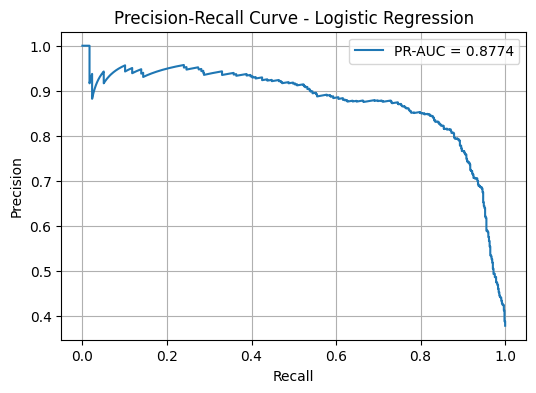

In [30]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))

plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

# Hyperparameter Optimization
Logistic Regression 모델의 성능 향상을 위해 하이퍼파라미터 튜닝을 수행한다.

## 14. Hyperparameter Search 범위 설정
GridSearchCV에서 탐색할 파라미터 범위를 정의한다.

In [37]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__class_weight': [None, 'balanced'],
    'model__solver': ['lbfgs', 'liblinear']
}

## 15. GridSearchCV 실행
Recall을 기준으로 최적의 하이퍼파라미터를 탐색한다.

In [38]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best score: 0.8906309751434035


C:\Users\minhakim\anaconda3\envs\aistudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 16. Best Model 저장
튜닝을 통해 얻은 최적 모델을 저장한다.

In [40]:
best_model = grid.best_estimator_

## 17. Tuned 모델 예측
최적 모델을 사용하여 테스트 데이터를 예측한다.

In [41]:
tuned_pred = best_model.predict(X_test)
tuned_pred_proba = best_model.predict_proba(X_test)[:,1]

## 18. Tuned 모델 평가
튜닝된 모델의 성능을 평가한다.

In [42]:
print(classification_report(y_test, tuned_pred))
print(confusion_matrix(y_test, tuned_pred))

print("Precision:", precision_score(y_test, tuned_pred))
print("Recall:", recall_score(y_test, tuned_pred))
print("F1:", f1_score(y_test, tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, tuned_pred_proba))
print("PR-AUC:", average_precision_score(y_test, tuned_pred_proba))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1071
           1       0.80      0.88      0.84       654

    accuracy                           0.87      1725
   macro avg       0.86      0.87      0.86      1725
weighted avg       0.87      0.87      0.87      1725

[[924 147]
 [ 79 575]]
Precision: 0.796398891966759
Recall: 0.8792048929663608
F1: 0.8357558139534884
ROC-AUC: 0.925393398949794
PR-AUC: 0.8770785931527142


## 19. Threshold 성능 비교
여러 threshold 값에 대해 precision / recall / f1-score를 비교한다.

In [45]:
threshold_list = np.arange(0.9, 0.05, -0.05)

threshold_result = []

for threshold in threshold_list:

    pred_threshold = (tuned_pred_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold),
        "f1": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_result)

threshold_df

,threshold,precision,recall,f1
0,0.90,0.939394,0.331804,0.490395
1,0.85,0.930000,0.426606,0.584906
2,0.80,0.906417,0.518349,0.659533
3,0.75,0.889145,0.588685,0.708372
4,0.70,0.876016,0.659021,0.752182
5,0.65,0.872302,0.741590,0.801653
6,0.60,0.851613,0.807339,0.828885
7,0.55,0.820208,0.844037,0.831952
8,0.50,0.796399,0.879205,0.835756
9,0.45,0.764935,0.900612,0.827247


## 20. Threshold별 성능 시각화
threshold 변화에 따라 Precision, Recall, F1-score가 어떻게 변하는지 확인한다.

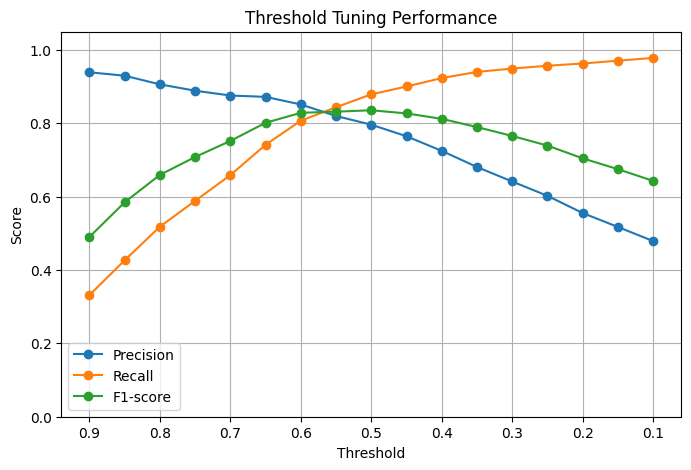

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Performance')
plt.gca().invert_xaxis()  # threshold가 낮아지는 방향으로 보기 쉽게
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 21. Precision-Recall Trade-off 시각화
threshold를 낮출수록 Recall이 증가하고 Precision이 감소하는 패턴을 확인한다.

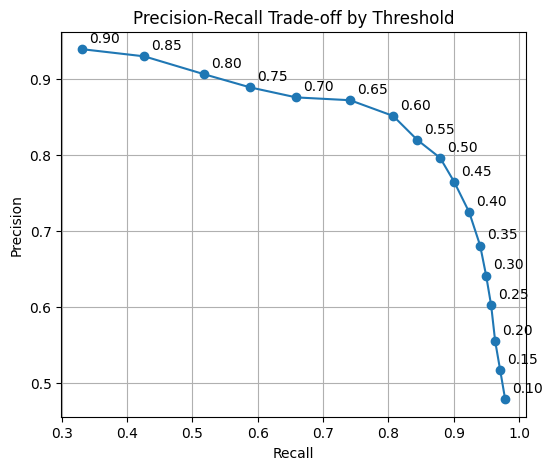

In [47]:
plt.figure(figsize=(6, 5))

plt.plot(
    threshold_df['recall'],
    threshold_df['precision'],
    marker='o'
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row['recall'], row['precision']),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off by Threshold')
plt.grid(True)
plt.show()

## 22. 최종 Threshold 적용
선택한 threshold를 적용하여 최종 모델 성능을 평가한다.

In [48]:
best_threshold = 0.80

pred_final = (tuned_pred_proba >= best_threshold).astype(int)

print("Precision:", precision_score(y_test, pred_final))
print("Recall:", recall_score(y_test, pred_final))
print("F1:", f1_score(y_test, pred_final))
print("ROC-AUC:", roc_auc_score(y_test, tuned_pred_proba))
print("PR-AUC:", average_precision_score(y_test, tuned_pred_proba))

print("\nClassification Report")
print(classification_report(y_test, pred_final))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_final))

Precision: 0.9064171122994652
Recall: 0.518348623853211
F1: 0.6595330739299611
ROC-AUC: 0.925393398949794
PR-AUC: 0.8770785931527142

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      1071
           1       0.91      0.52      0.66       654

    accuracy                           0.80      1725
   macro avg       0.84      0.74      0.76      1725
weighted avg       0.82      0.80      0.78      1725


Confusion Matrix
[[1036   35]
 [ 315  339]]


# Feature Importance

## 23. coefficient를 이용한 주요 변수 추출
튜닝된 Logistic Regression 모델의 변수 중요도를 확인한다.

In [50]:
# feature 이름
feature_names = X_train.columns

# coefficient
coef = best_model.named_steps['model'].coef_[0]

# importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

# 절대값 기준 정렬
importance_df['abs_coef'] = importance_df['coefficient'].abs()
importance_df = importance_df.sort_values(by='abs_coef', ascending=False)

print(importance_df.head(10))

                  feature  coefficient  abs_coef
12           avg_progress     0.676640  0.676640
7        total_watch_time     0.668747  0.668747
8          avg_watch_time     0.631339  0.631339
11  days_since_last_watch     0.590042  0.590042
1               plan_tier     0.539320  0.539320
0                     age     0.507924  0.507924
3               age_group     0.488983  0.488983
9              watch_days     0.433605  0.433605
2           monthly_spend     0.396081  0.396081
6           unique_movies     0.379202  0.379202


## 24. Feature Importance 시각화

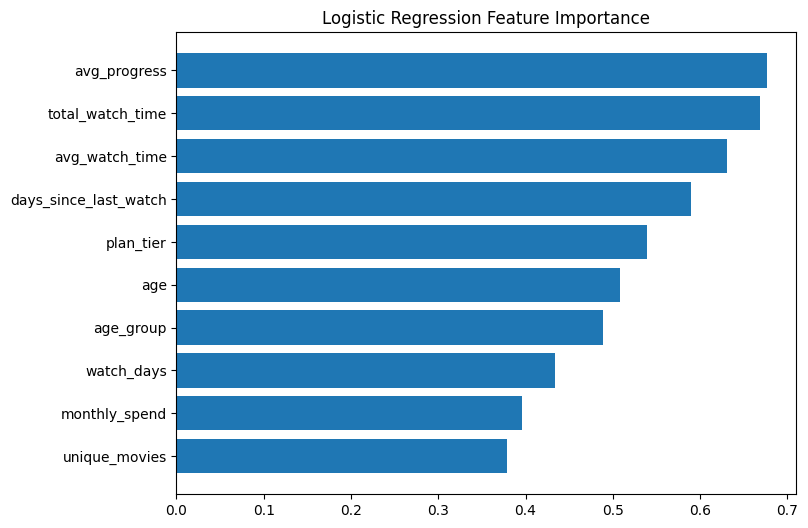

In [52]:
top10 = importance_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10['feature'], top10['coefficient'])
plt.title("Logistic Regression Feature Importance")
plt.gca().invert_yaxis()
plt.show()